# I) Binary liver segmentation: Data Preparation
## Mansour Arefi
### CM2026 Advanced Machine Learning for Data-driven-Health


This notebook prepares a dataset for this assignment.

This notebook contain: 
- load raw 3D CT data and corresponding liver masks from KTH cloud,
- convert them into a compact local cache format,
- create a patient-level train/validation/test split,
- estimate normalization statistics from the training set only,


The notebook produces (the output):
- compressed patient volumes in `.npz` format,
- a metadata table describing the cached patients,
- a patient-level data split,
- and global dataset statistics for later normalization (valid if we use the whole dataset).

This notebook is the first step of the pipeline and is used as input (dataset) for the training notebook.

In [25]:
%pip install -q s3fs python-dotenv pandas nibabel matplotlib tqdm

Note: you may need to restart the kernel to use updated packages.


## 1. Imports

### Comments:
- After trying with different amount of patients I chose the maximum amount of patients I would be able to use for trainíng is 100. 
- The clipping range is chosen to focus on soft-tissue intensities relevant for liver segmentation.

In [26]:
import os
import gc
import json
import gzip
import random
from pathlib import Path

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import s3fs
from dotenv import load_dotenv
from tqdm.auto import tqdm

# Paths
BASE = Path("/kaggle/working/abdomen_cache_volumes")
VOLUME_DIR = BASE / "volumes"
META_DIR = BASE / "meta"

VOLUME_DIR.mkdir(parents=True, exist_ok=True)
META_DIR.mkdir(parents=True, exist_ok=True)

PATIENT_INDEX_CSV = META_DIR / "patient_index.csv"
FAILED_CASES_CSV = META_DIR / "failed_cases.csv"
SPLIT_JSON = META_DIR / "split.json"
STATS_JSON = META_DIR / "stats.json"

# Parameters
TARGET_PATIENTS = 100 
SEED = 42
CLIP_RANGE = (-100, 400)

print("BASE:", BASE)
print("VOLUME_DIR:", VOLUME_DIR)
print("META_DIR:", META_DIR)

BASE: /kaggle/working/abdomen_cache_volumes
VOLUME_DIR: /kaggle/working/abdomen_cache_volumes/volumes
META_DIR: /kaggle/working/abdomen_cache_volumes/meta


## 2. Credential to access KTH cloud
The Credentials should not be hardcoded like this but could not find a way to include a env file in kaggle.

In [ ]:
AWS_ACCESS_KEY_ID = ""
AWS_SECRET_ACCESS_KEY = ""
AWS_REGION = "kthcloud"
S3_ENDPOINT = ""
S3_BUCKET = "cm2026"

print("AWS_ACCESS_KEY_ID:", AWS_ACCESS_KEY_ID is not None)
print("AWS_SECRET_ACCESS_KEY:", AWS_SECRET_ACCESS_KEY is not None)
print("AWS_DEFAULT_REGION:", AWS_REGION is not None)
print("S3_ENDPOINT:", S3_ENDPOINT is not None)
print("S3_BUCKET:", S3_BUCKET is not None)
print("Bucket:", S3_BUCKET)

fs = s3fs.S3FileSystem(
    key=AWS_ACCESS_KEY_ID,
    secret=AWS_SECRET_ACCESS_KEY,
    client_kwargs={
        "region_name": AWS_REGION,
        "endpoint_url": S3_ENDPOINT
    }
)

print("S3 filesystem created.")

AWS_ACCESS_KEY_ID: True
AWS_SECRET_ACCESS_KEY: True
AWS_DEFAULT_REGION: True
S3_ENDPOINT: True
S3_BUCKET: True
Bucket: cm2026
S3 filesystem created.


## 3. Helper functions for loading and find paths for the data

In [28]:
def load_nifti_from_stream(stream):
    with gzip.GzipFile(fileobj=stream) as gz:
        img_bytes = gz.read()
    img = nib.Nifti1Image.from_bytes(img_bytes)
    return img


def load_nifti_from_s3(s3_path):
    with fs.open(s3_path, "rb") as s3_file:
        img = load_nifti_from_stream(s3_file)
    return img


def get_case_paths(fs, case_folder):
    all_files = fs.find(case_folder)

    ct_files = [x for x in all_files if x.lower().endswith("ct.nii.gz")]
    liver_files = [x for x in all_files if "segmentations/liver.nii" in x.lower()]

    if len(ct_files) != 1:
        raise ValueError(f"Expected 1 CT file in {case_folder}, found {len(ct_files)}")
    if len(liver_files) != 1:
        raise ValueError(f"Expected 1 liver file in {case_folder}, found {len(liver_files)}")

    return ct_files[0], liver_files[0]


def load_case(fs, case_folder, canonical=True):
    ct_file, liver_file = get_case_paths(fs, case_folder)

    ct_img = load_nifti_from_s3(ct_file)
    liver_img = load_nifti_from_s3(liver_file)

    if canonical:
        ct_img = nib.as_closest_canonical(ct_img)
        liver_img = nib.as_closest_canonical(liver_img)

    ct_vol = ct_img.get_fdata(dtype=np.float32)
    liver_vol = liver_img.get_fdata(dtype=np.float32)

    # binary mask
    liver_vol = (liver_vol > 0).astype(np.uint8)

    return ct_vol, liver_vol


def case_id_from_folder(case_folder):
    return case_folder.split("/")[-1]


## 4. Connect to the cloud

In [29]:
bucket_contents = fs.ls(S3_BUCKET)
patient_folders = sorted([x for x in bucket_contents if "BDMAP_" in x])

print("Number of patient folders in bucket:", len(patient_folders))
print("First 5:")
for x in patient_folders[:5]:
    print(x)


Number of patient folders in bucket: 5195
First 5:
cm2026/BDMAP_00000001
cm2026/BDMAP_00000002
cm2026/BDMAP_00000003
cm2026/BDMAP_00000004
cm2026/BDMAP_00000005


In [30]:
desired_patients = patient_folders[:TARGET_PATIENTS]
print("\n Desired patients:", len(desired_patients))


 Desired patients: 100


## 5. Create the volumes
It will be both the ct_vol + liver_vol for each patient under same file named as the patient folder in the bucket: BDMAP_000000xx

---> volumes/BDMAP_000000xx


In [31]:
def cache_patient_volume(fs, case_folder):
    case_id = case_id_from_folder(case_folder)
    npz_name = f"{case_id}.npz"
    out_file = VOLUME_DIR / npz_name

    ct_vol, liver_vol = load_case(fs, case_folder, canonical=True)

    positive_per_slice = liver_vol.sum(axis=(0, 1)) > 0

    row = {
        "case_id": case_id,
        "case_folder": case_folder,
        "npz_name": npz_name,
        "height": int(ct_vol.shape[0]),
        "width": int(ct_vol.shape[1]),
        "depth": int(ct_vol.shape[2]),
        "positive_slices": int(positive_per_slice.sum()),
        "negative_slices": int(len(positive_per_slice) - positive_per_slice.sum()),
        "ct_min": float(ct_vol.min()),
        "ct_max": float(ct_vol.max()),
    }

    np.savez_compressed(
        out_file,
        ct_vol=ct_vol.astype(np.float32),
        liver_vol=liver_vol.astype(np.uint8),
    )

    del ct_vol, liver_vol, positive_per_slice
    gc.collect()

    return row

In [32]:
succeeded_rows = []
failed_rows = []

for case_folder in tqdm(patients_to_cache, desc="Caching patient volumes"):
    try:
        row = cache_patient_volume(fs, case_folder)
        succeeded_rows.append(row)
    except Exception as e:
        failed_rows.append({
            "case_folder": case_folder,
            "error": str(e)
        })

df_new = pd.DataFrame(succeeded_rows)
df_failed = pd.DataFrame(failed_rows)

# behåll bara de patienter vi faktiskt vill ha i denna version
desired_ids = {case_id_from_folder(p) for p in desired_patients}
df_keep_existing = df_existing[df_existing["case_id"].isin(desired_ids)].copy()

df_all = pd.concat([df_keep_existing, df_new], ignore_index=True)
df_all = df_all.drop_duplicates(subset=["case_id"]).sort_values("case_id").reset_index(drop=True)

df_all.to_csv(PATIENT_INDEX_CSV, index=False)
df_failed.to_csv(FAILED_CASES_CSV, index=False)

print("Succeeded cached this run:", len(df_new))
print("Failed this run:", len(df_failed))
print("Total cached patients now:", len(df_all))
df_all

Caching patient volumes:   0%|          | 0/100 [00:00<?, ?it/s]

Succeeded cached this run: 100
Failed this run: 0
Total cached patients now: 100


/tmp/ipykernel_55/180113763.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all = pd.concat([df_keep_existing, df_new], ignore_index=True)


,case_id,case_folder,npz_name,height,width,depth,positive_slices,negative_slices,ct_min,ct_max
0,BDMAP_00000001,cm2026/BDMAP_00000001,BDMAP_00000001.npz,511,404,339,55,284,-1000.0,1000.0
1,BDMAP_00000002,cm2026/BDMAP_00000002,BDMAP_00000002.npz,403,313,201,155,46,-999.0,999.0
2,BDMAP_00000003,cm2026/BDMAP_00000003,BDMAP_00000003.npz,301,212,215,138,77,-999.0,999.0
3,BDMAP_00000004,cm2026/BDMAP_00000004,BDMAP_00000004.npz,512,368,91,30,61,-999.0,999.0
4,BDMAP_00000005,cm2026/BDMAP_00000005,BDMAP_00000005.npz,512,395,509,187,322,-1000.0,1000.0
...,...,...,...,...,...,...,...,...,...,...
95,BDMAP_00000096,cm2026/BDMAP_00000096,BDMAP_00000096.npz,512,362,81,31,50,-999.0,999.0
96,BDMAP_00000097,cm2026/BDMAP_00000097,BDMAP_00000097.npz,512,368,532,230,302,-1000.0,1000.0
97,BDMAP_00000098,cm2026/BDMAP_00000098,BDMAP_00000098.npz,512,356,978,229,749,-1000.0,1000.0
98,BDMAP_00000099,cm2026/BDMAP_00000099,BDMAP_00000099.npz,512,482,532,199,333,-1000.0,1000.0


## 6. Set the split and calculated statics of data
We created two json with the split and statics of the data
- split as train 60% , val 20% & test 20% --->split.json
- Calculated mean & std (and include the clip range) --->stats.json

In [33]:
random.seed(SEED)

case_ids = sorted(df_all["case_id"].tolist())
random.shuffle(case_ids)

n = len(case_ids)
n_test = max(1, int(0.2 * n))
n_val = max(1, int(0.2 * n))

split = {
    "test": case_ids[:n_test],
    "val": case_ids[n_test:n_test + n_val],
    "train": case_ids[n_test + n_val:],
}

with open(SPLIT_JSON, "w") as f:
    json.dump(split, f, indent=2)

print("Train patients:", len(split["train"]), split["train"])
print("Val patients:", len(split["val"]), split["val"])
print("Test patients:", len(split["test"]), split["test"])

Train patients: 60 ['BDMAP_00000037', 'BDMAP_00000024', 'BDMAP_00000040', 'BDMAP_00000041', 'BDMAP_00000019', 'BDMAP_00000067', 'BDMAP_00000062', 'BDMAP_00000061', 'BDMAP_00000008', 'BDMAP_00000035', 'BDMAP_00000100', 'BDMAP_00000047', 'BDMAP_00000003', 'BDMAP_00000052', 'BDMAP_00000017', 'BDMAP_00000039', 'BDMAP_00000059', 'BDMAP_00000069', 'BDMAP_00000023', 'BDMAP_00000063', 'BDMAP_00000025', 'BDMAP_00000006', 'BDMAP_00000007', 'BDMAP_00000068', 'BDMAP_00000083', 'BDMAP_00000020', 'BDMAP_00000080', 'BDMAP_00000044', 'BDMAP_00000091', 'BDMAP_00000021', 'BDMAP_00000001', 'BDMAP_00000096', 'BDMAP_00000058', 'BDMAP_00000094', 'BDMAP_00000054', 'BDMAP_00000090', 'BDMAP_00000026', 'BDMAP_00000072', 'BDMAP_00000085', 'BDMAP_00000078', 'BDMAP_00000065', 'BDMAP_00000030', 'BDMAP_00000028', 'BDMAP_00000089', 'BDMAP_00000098', 'BDMAP_00000005', 'BDMAP_00000055', 'BDMAP_00000076', 'BDMAP_00000012', 'BDMAP_00000070', 'BDMAP_00000087', 'BDMAP_00000014', 'BDMAP_00000018', 'BDMAP_00000029', 'BDMAP_0

In [34]:
def estimate_mean_std_from_cached_volumes(case_ids, volume_dir, clip_range=(-100, 400)):
    values_sum = 0.0
    values_sq_sum = 0.0
    n_pixels = 0

    for case_id in tqdm(case_ids, desc="Estimating mean/std"):
        data = np.load(volume_dir / f"{case_id}.npz")
        ct_vol = data["ct_vol"].astype(np.float32)
        ct_vol = np.clip(ct_vol, *clip_range)

        values_sum += ct_vol.sum()
        values_sq_sum += (ct_vol ** 2).sum()
        n_pixels += ct_vol.size

    mean = values_sum / n_pixels
    std = np.sqrt(values_sq_sum / n_pixels - mean ** 2)
    return float(mean), float(std)


dataset_mean, dataset_std = estimate_mean_std_from_cached_volumes(
    split["train"],
    VOLUME_DIR,
    clip_range=CLIP_RANGE
)

stats = {
    "mean": dataset_mean,
    "std": dataset_std,
    "clip_range": list(CLIP_RANGE),
    "target_patients": TARGET_PATIENTS,
}

with open(STATS_JSON, "w") as f:
    json.dump(stats, f, indent=2)

print("dataset_mean:", dataset_mean)
print("dataset_std:", dataset_std)

Estimating mean/std:   0%|          | 0/60 [00:00<?, ?it/s]

dataset_mean: -41.84754180908203
dataset_std: 96.74005889892578


## 7. Visualization of a sample

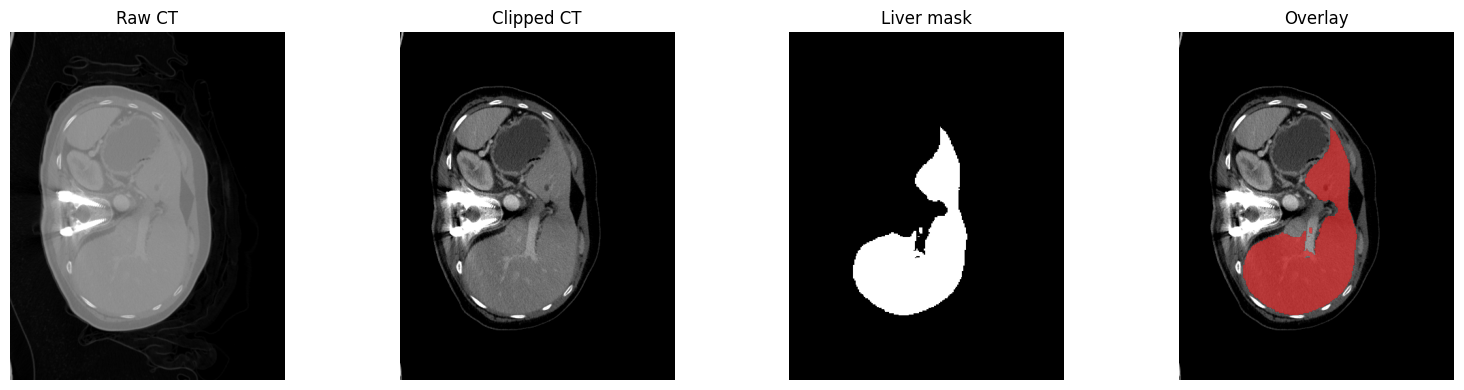

Sample case: BDMAP_00000001
Shape: (511, 404, 339)
Chosen slice: 161
Positive slices: 55


In [35]:
sample_case_id = df_all.iloc[0]["case_id"]
sample_file = VOLUME_DIR / f"{sample_case_id}.npz"

sample = np.load(sample_file)
ct_vol = sample["ct_vol"]
liver_vol = sample["liver_vol"]

positive_slices = np.where(liver_vol.sum(axis=(0, 1)) > 0)[0]

if len(positive_slices) > 0:
    z = int(positive_slices[len(positive_slices) // 2])
else:
    z = ct_vol.shape[2] // 2

ct_slice = ct_vol[:, :, z]
ct_slice_clipped = np.clip(ct_slice, *CLIP_RANGE)
mask_slice = liver_vol[:, :, z]
mask_overlay = np.ma.masked_where(mask_slice == 0, mask_slice)

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.title("Raw CT")
plt.imshow(ct_slice, cmap="gray")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.title("Clipped CT")
plt.imshow(ct_slice_clipped, cmap="gray")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.title("Liver mask")
plt.imshow(mask_slice, cmap="gray")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.title("Overlay")
plt.imshow(ct_slice_clipped, cmap="gray")
plt.imshow(mask_overlay, cmap="autumn", alpha=0.5)
plt.axis("off")

plt.tight_layout()
plt.show()

print("Sample case:", sample_case_id)
print("Shape:", ct_vol.shape)
print("Chosen slice:", z)
print("Positive slices:", len(positive_slices))

In [36]:
print("Files in META_DIR:")
for p in META_DIR.iterdir():
    print("-", p.name)

print("\nNumber of cached volume files:", len(list(VOLUME_DIR.glob("*.npz"))))

sample_case_file = next(VOLUME_DIR.glob("*.npz"))
sample_data = np.load(sample_case_file)

print("\nSample volume file:", sample_case_file.name)
print("ct_vol shape:", sample_data["ct_vol"].shape, sample_data["ct_vol"].dtype)
print("liver_vol shape:", sample_data["liver_vol"].shape, sample_data["liver_vol"].dtype)

Files in META_DIR:
- split.json
- failed_cases.csv
- patient_index.csv
- stats.json

Number of cached volume files: 100

Sample volume file: BDMAP_00000023.npz
ct_vol shape: (512, 389, 102) float32
liver_vol shape: (512, 389, 102) uint8


## Summary:

I this notebook we have chosen the first 100 patients, extracted the CT_volym together corresponded binary liver mask + split the data for training + estimated the mean and std at the chosen clipp range. Everything is saved to the output in order to be able to create a "Preprocessed/prepared" dataset so we can use in the training step, without connection to the cloud which can be challenging. 